# Adiabatic error cancellation in Berry phase estimation

All experiments and figures for the paper, in one notebook. The reusable physics
lives in the `berry_cancellation` package (loop models + estimators); this notebook
only drives it and plots. Run top to bottom.

The cancellation cascade on a closed adiabatic loop:

| estimator | leading error |
|---|---|
| single evolution | $O(T^{-1})$ |
| forward&ndash;reverse (averages $\pm H$) | $O(T^{-2})$, oscillatory |
| + Richardson extrapolation | removes the non-oscillatory $T^{-2}$ |
| + runtime randomization ($C^\infty$ bump) | suppresses the oscillatory residual |

Two loop models are studied. For each we **first validate the Berry phase** (so the
estimator is targeting the right geometric quantity) and **then demonstrate the
cancellation**: a spin-$1/2$ in a cone field (exactly solvable, analytic Berry
phase), and a spiral Heisenberg chain (a genuinely entangled many-qubit loop).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from berry_cancellation import SpinHalfLoop, berry_phase_wilson
from berry_cancellation.manybody import SpiralHeisenbergChain
from berry_cancellation.estimators import (
    single_phase_error, forward_reverse_error, richardson_error,
    randomized_richardson_bias, _theta_B_forward_reverse, default_steps,
)
from berry_cancellation.reference import wrap_to_half_pi, wrap_to_pi

## 1. Spin-1/2 Berry-phase validation

As a controlled testbed we use a spin-$1/2$ in a magnetic field of fixed magnitude
swept around a cone of half-angle $\theta_0$ on the Bloch sphere,
$H(s) = -\tfrac{1}{2}\,\mathbf{B}(s)\!\cdot\!\boldsymbol{\sigma}$, with $\mathbf{B}(s)$
tracing the cone over $s\in[0,1]$. The ground-state Berry phase is known in closed
form, $\theta_B = -\Omega/2 = -\pi(1-\cos\theta_0)$, where $\Omega$ is the solid
angle enclosed by the loop. Before applying the cancellation protocol we confirm
that the pipeline targets this value: across $\theta_0\in[0.15\pi,\,0.85\pi]$ the
analytic $\theta_B$, the gauge-invariant Wilson-loop evaluation, and the
forward&ndash;reverse estimate at finite runtime $T=120$ coincide &mdash; the Wilson
loop to $2.5\times10^{-7}$ and the finite-$T$ estimate to $1.7\times10^{-3}$.

**Caption.** Berry-phase validation on the spin-$1/2$ cone loop. Ground-state Berry
phase $\theta_B$ versus cone half-angle $\theta_0$: the exact analytic value
$-\pi(1-\cos\theta_0)$ (solid line), the gauge-invariant Wilson loop (circles), and
the forward&ndash;reverse estimate at runtime $T=120$ (crosses). The three
determinations agree over the full range (maximum deviation $2.5\times10^{-7}$ for
the Wilson loop and $1.7\times10^{-3}$ for the finite-$T$ estimate), confirming that
the estimator targets the correct geometric phase before any error cancellation is
applied.

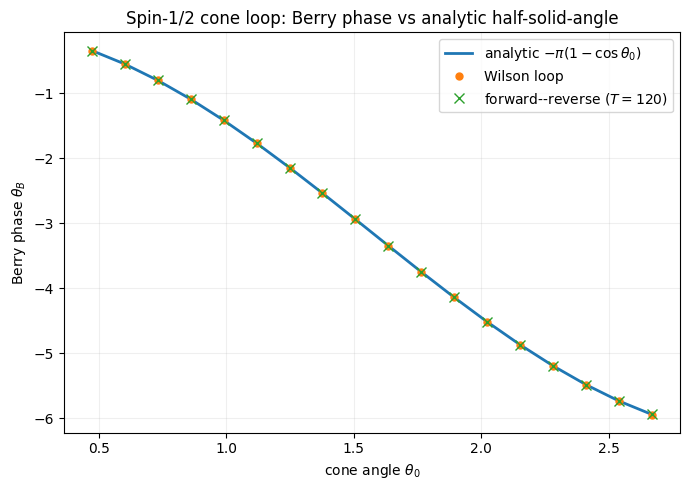

max |analytic - wilson|   = 2.48e-07
max |analytic - estimate| = 1.69e-03


In [2]:
thetas = np.linspace(0.15 * np.pi, 0.85 * np.pi, 18)
T = 120.0
analytic, wilson, estimate = [], [], []
for th in thetas:
    m = SpinHalfLoop(theta0=float(th))
    ref = m.berry_phase
    analytic.append(ref)
    wil = berry_phase_wilson(m)
    wilson.append(ref + (wil - ref + np.pi) % (2 * np.pi) - np.pi)
    est = _theta_B_forward_reverse(m, T, default_steps(T))
    estimate.append(ref + float(wrap_to_half_pi(est - ref)))

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.plot(thetas, analytic, "-", lw=2, label=r"analytic $-\pi(1-\cos\theta_0)$")
ax.plot(thetas, wilson, "o", ms=5, label="Wilson loop")
ax.plot(thetas, estimate, "x", ms=7, label=rf"forward--reverse ($T={T:.0f}$)")
ax.set_xlabel(r"cone angle $\theta_0$")
ax.set_ylabel(r"Berry phase $\theta_B$")
ax.set_title("Spin-1/2 cone loop: Berry phase vs analytic half-solid-angle")
ax.legend()
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()
print(f"max |analytic - wilson|   = {np.max(np.abs(np.array(analytic) - wilson)):.2e}")
print(f"max |analytic - estimate| = {np.max(np.abs(np.array(analytic) - estimate)):.2e}")

## 2. Cancellation cascade (spin-1/2 cone loop)

This is the central result on the exactly solvable spin-$1/2$ cone loop (constant
gap $\Delta=|B|=1$, $\theta_0=0.4\pi$, $\theta_B=-2.1708$). It plots the magnitude
of the Berry-phase error for the four estimators against the total runtime $T$. A
single adiabatic traversal incurs an error $O(T^{-1})$. Averaging the eigenphases of
the forward ($+H$) and reverse ($-H$) evolutions cancels the dynamical phase
together with the leading non-adiabatic term, leaving $O(T^{-2})$. A two-runtime
Richardson extrapolation removes the remaining *non-oscillatory* $T^{-2}$
contribution, and randomizing the runtime over a smooth ($C^\infty$) "bump"
distribution suppresses the residual *oscillatory* term faster than any power of
$1/T$. The net scaling improves by one Richardson level at a time: $O(T^{-4})$ with
one level and $O(T^{-6})$ with two. At two levels the non-oscillatory floor drops
below the residual oscillation, so that curve becomes oscillation-limited and its
magnitude dips sharply wherever the signed bias crosses zero, while its envelope
still follows $T^{-6}$. Randomization parameters: half-width $\lambda=0.7$ and
Richardson step $\alpha=1.75$, giving worst-case runtimes $T(1+\lambda)\alpha^{\ell}$
of $298$ (one level) and $521$ (two levels) at $T=100$.

**Caption.** Adiabatic error-cancellation cascade on the spin-$1/2$ cone loop.
Berry-phase error $|\tilde\theta_B-\theta_B|$ versus runtime $T$ for the four
estimators: single evolution ($\circ$, $\propto T^{-1}$), forward&ndash;reverse
averaging of $\pm H$ ($\square$, $\propto T^{-2}$), one Richardson level with a
bump-randomized runtime ($\triangle$, $\propto T^{-4}$), and two Richardson levels
with bump randomization ($\diamond$, $\propto T^{-6}$); grey lines are the reference
slopes. Each Richardson level cancels the next non-oscillatory term, and the
$C^\infty$ bump distribution suppresses the oscillatory residual super-polynomially.
Parameters: $T\in[8,100]$ (20 points), $\lambda=0.7$, $\alpha=1.75$. The two-level
curve sits at its $T^{-6}$ floor and is oscillation-limited &mdash; its downward
spikes are zero crossings of the signed bias, not a change of scaling.

spin-1/2 cone loop: theta0=1.2566, gap=1.0, theta_B=-2.170787


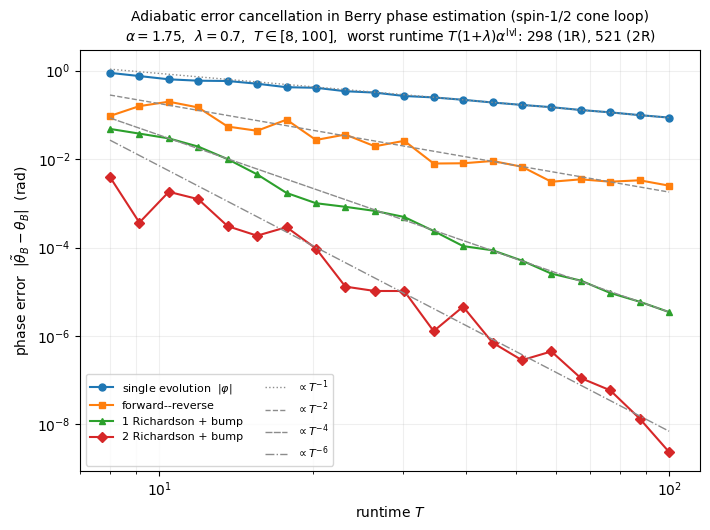

In [3]:
model = SpinHalfLoop()
print(f"spin-1/2 cone loop: theta0={model.theta0:.4f}, gap={model.gap}, theta_B={model.berry_phase:.6f}")

LAM, ALPHA, T_MAX, N_POINTS = 0.7, 1.75, 100.0, 20
T = np.geomspace(8.0, T_MAX, N_POINTS)

e_single = single_phase_error(model, T)
e_fr = forward_reverse_error(model, T)
e_bump1 = randomized_richardson_bias(model, T, alpha=ALPHA, lam=LAM, levels=1, dist="bump")
e_bump2 = randomized_richardson_bias(model, T, alpha=ALPHA, lam=LAM, levels=2, dist="bump")

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.loglog(T, e_single, "o-", ms=5, color="C0", label=r"single evolution  $|\varphi|$")
ax.loglog(T, e_fr, "s-", ms=5, color="C1", label=r"forward--reverse")
ax.loglog(T, e_bump1, "^-", ms=5, color="C2", label=r"1 Richardson + bump")
ax.loglog(T, e_bump2, "D-", ms=5, color="C3", label=r"2 Richardson + bump")
tail = T >= np.sqrt(8.0 * T_MAX)
for power, e, style in [(-1, e_single, ":"), (-2, e_fr, "--"), (-4, e_bump1, (0, (5, 1))), (-6, e_bump2, "-.")]:
    c = np.median(e[tail] / T[tail] ** power)
    ax.loglog(T, c * T ** power, color="0.55", lw=1.0, linestyle=style, label=rf"$\propto T^{{{power}}}$")
worst1, worst2 = T_MAX * (1.0 + LAM) * ALPHA, T_MAX * (1.0 + LAM) * ALPHA**2
params = (rf"$\alpha={ALPHA:g}$,  $\lambda={LAM:g}$,  $T\in[8,{T_MAX:g}]$,  "
          rf"worst runtime $T(1{{+}}\lambda)\alpha^{{\rm lvl}}$: {worst1:.0f} (1R), {worst2:.0f} (2R)")
ax.set_xlim(7.0, T_MAX * 1.15)
ax.set_xlabel("runtime $T$")
ax.set_ylabel(r"phase error  $|\tilde\theta_B - \theta_B|$  (rad)")
ax.set_title("Adiabatic error cancellation in Berry phase estimation (spin-1/2 cone loop)\n" + params, fontsize=10)
ax.legend(fontsize=8, ncol=2, loc="lower left")
ax.grid(True, which="both", alpha=0.2)
fig.tight_layout()
plt.show()

## 3. Theory bounds, and which gap controls each estimator (spin-1/2)

To check the analytic error bounds and, in particular, to identify *which* spectral
gap governs each stage of the cascade, we deform the loop into a non-isospectral one
by modulating the field magnitude, $|B(s)| = |B|\,(1 - a\sin^2\pi s)$ with $a=0.4$.
This lowers the gap in the *interior* of the loop to $\Delta_{\min}=0.6$ while
leaving the *endpoint* quantities &mdash; the gap $\Delta(0)=1$ and the rate
$\|\dot H(0)\|$ &mdash; unchanged, and it leaves the Berry phase invariant
(panel a). The single-evolution error is set by the interior worst-case gap:
$|\varphi|\lesssim \|\dot H\|_{\max}^2/(\Delta_{\min}^3\,T)$, so the dip raises both
the numerics and (more steeply) the bound (panel b). The Richardson residual, in
contrast, is an endpoint-controlled boundary term $\sim\|\dot H(0)\|^2/(\Delta(0)^4
T^2)$: the dipped and undipped data fall on the *same* line, independent of the
interior gap (panel c). Finally the randomized one-Richardson bias obeys the
Theorem-3 estimate, which for a $C^\infty$ bump (effective $M=2$) reads
$C\,\|\dot H(0)\|^2/(\Delta(0)^4\,\Delta_{\min}^2\,T^4)$; a single constant
$C\approx48$ upper-bounds both curves (panel d), confirming the joint dependence on
the endpoint gap $\Delta(0)$ and the interior gap $\Delta_{\min}$.

**Caption.** Numerics against the analytic bounds, and the controlling gap for each
estimator, on a non-isospectral spin-$1/2$ loop with field modulation
$|B(s)|=|B|(1-a\sin^2\pi s)$, $a=0.4$. (a) Instantaneous gap $\Delta(s)$: constant
($a=0$, dashed) versus dipped to $\Delta_{\min}=0.6$ in the interior (solid), with
the endpoints fixed at $\Delta(0)=1$. (b) Single-evolution error with the worst-case
bound $\|\dot H\|_{\max}^2/(\Delta_{\min}^3 T)$ for the dipped and undipped loops:
the error tracks the *interior* gap $\Delta_{\min}$. (c) One-Richardson residual:
dipped and undipped data collapse onto the same endpoint-controlled line
$\|\dot H(0)\|^2/(\Delta(0)^4 T^2)$, independent of $\Delta_{\min}$. (d) One
Richardson with bump randomization and the Theorem-3 ($M=2$) upper bound
$C\,\|\dot H(0)\|^2/(\Delta(0)^4\Delta_{\min}^2 T^4)$; one constant $C\approx48$
bounds both loops. $T\in[20,400]$.

upper-bound constant C=47.9


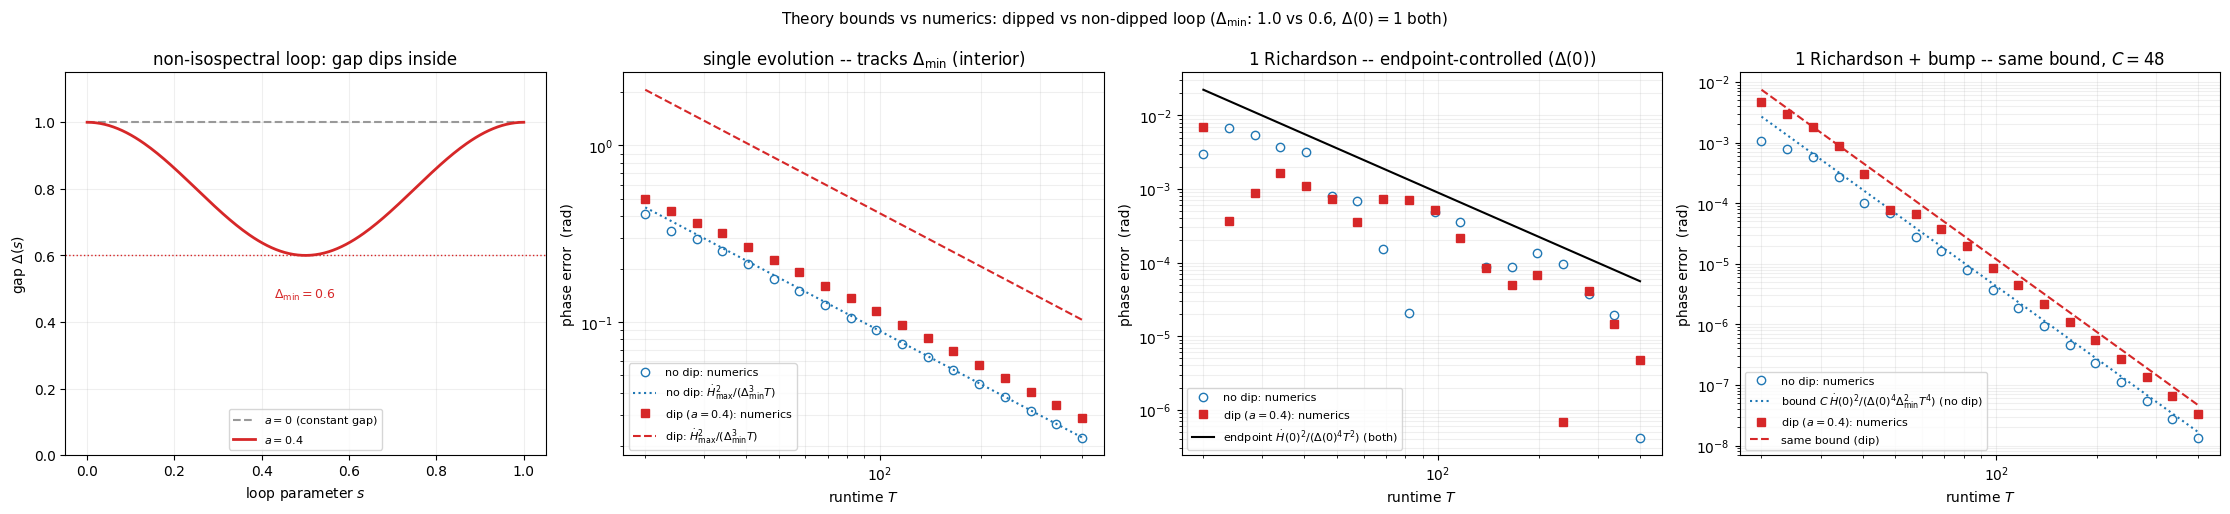

In [4]:
A = 0.4
T_MIN, T_MAX, N_POINTS = 20.0, 400.0, 18

def hdot_norm(model, s, h=1e-6):
    return np.linalg.norm(model.H(s + h) - model.H(s - h), 2) / (2 * h)

def info(model):
    s = np.linspace(0.0, 1.0, 400, endpoint=False)
    Hmax = max(hdot_norm(model, si) for si in s)
    return Hmax, model.gap, hdot_norm(model, 0.0), model.gap_at(0.0)

T = np.geomspace(T_MIN, T_MAX, N_POINTS)
flat = SpinHalfLoop(gap_dip=0.0)
dip = SpinHalfLoop(gap_dip=A)
Hmf, Dmf, H0f, D0f = info(flat)
Hmd, Dmd, H0d, D0d = info(dip)

fig, (ax0, axL, axR, axC) = plt.subplots(1, 4, figsize=(22.4, 5.2))

# Panel 0: the dipping gap Delta(s) along the loop.
s = np.linspace(0.0, 1.0, 200)
ax0.plot(s, np.ones_like(s) * flat.field, "--", color="0.6", label=r"$a=0$ (constant gap)")
ax0.plot(s, [dip.gap_at(si) for si in s], "-", color="C3", lw=2, label=rf"$a={A}$")
ax0.axhline(dip.gap, color="C3", ls=":", lw=1)
ax0.annotate(rf"$\Delta_{{\min}}={dip.gap:.1f}$", xy=(0.5, dip.gap),
             xytext=(0.5, dip.gap - 0.13), ha="center", fontsize=9, color="C3")
ax0.set_xlabel("loop parameter $s$")
ax0.set_ylabel(r"gap $\Delta(s)$")
ax0.set_title(r"non-isospectral loop: gap dips inside")
ax0.set_ylim(0, 1.15)
ax0.legend(loc="lower center", fontsize=8)
ax0.grid(True, alpha=0.2)

# Panel 1: single evolution, dip vs no dip.
axL.loglog(T, single_phase_error(flat, T), "o", ms=6, mfc="none", color="C0", label="no dip: numerics")
axL.loglog(T, Hmf**2 / Dmf**3 / T, ":", color="C0", lw=1.5, label=r"no dip: $\dot H_{\max}^2/(\Delta_{\min}^3 T)$")
axL.loglog(T, single_phase_error(dip, T), "s", ms=6, color="C3", label=rf"dip ($a={A}$): numerics")
axL.loglog(T, Hmd**2 / Dmd**3 / T, "--", color="C3", lw=1.5, label=r"dip: $\dot H_{\max}^2/(\Delta_{\min}^3 T)$")
axL.set_xlabel("runtime $T$")
axL.set_ylabel(r"phase error  (rad)")
axL.set_title(r"single evolution -- tracks $\Delta_{\min}$ (interior)")
axL.legend(fontsize=8, loc="lower left")
axL.grid(True, which="both", alpha=0.2)

# Panel 2: 1 Richardson, dip vs no dip.
axR.loglog(T, richardson_error(flat, T), "o", ms=6, mfc="none", color="C0", label="no dip: numerics")
axR.loglog(T, richardson_error(dip, T), "s", ms=6, color="C3", label=rf"dip ($a={A}$): numerics")
axR.loglog(T, H0d**2 / D0d**4 / T**2, "-", color="k", lw=1.5, label=r"endpoint $\dot H(0)^2/(\Delta(0)^4 T^2)$ (both)")
axR.set_xlabel("runtime $T$")
axR.set_ylabel(r"phase error  (rad)")
axR.set_title(r"1 Richardson -- endpoint-controlled ($\Delta(0)$)")
axR.legend(fontsize=8, loc="lower left")
axR.grid(True, which="both", alpha=0.2)

# Panel 3: 1 Richardson + bump randomization, with the Theorem-3 (M=2) upper bound.
bf = randomized_richardson_bias(flat, T, alpha=1.75, lam=0.7, levels=1, dist="bump")
bd = randomized_richardson_bias(dip, T, alpha=1.75, lam=0.7, levels=1, dist="bump")
base_f = H0f**2 / D0f**4 / Dmf**2
base_d = H0d**2 / D0d**4 / Dmd**2
C = max(np.max(bf * T**4 / base_f), np.max(bd * T**4 / base_d))
bound_f, bound_d = C * base_f / T**4, C * base_d / T**4
print(f"upper-bound constant C={C:.1f}")
axC.loglog(T, bf, "o", ms=6, mfc="none", color="C0", label="no dip: numerics")
axC.loglog(T, bound_f, ":", color="C0", lw=1.5, label=r"bound $C\,\dot H(0)^2/(\Delta(0)^4\Delta_{\min}^2 T^4)$ (no dip)")
axC.loglog(T, bd, "s", ms=6, color="C3", label=rf"dip ($a={A}$): numerics")
axC.loglog(T, bound_d, "--", color="C3", lw=1.5, label=r"same bound (dip)")
axC.set_xlabel("runtime $T$")
axC.set_ylabel(r"phase error  (rad)")
axC.set_title(rf"1 Richardson + bump -- same bound, $C={C:.0f}$")
axC.legend(fontsize=8, loc="lower left")
axC.grid(True, which="both", alpha=0.2)

fig.suptitle(rf"Theory bounds vs numerics: dipped vs non-dipped loop ($\Delta_{{\min}}$: 1.0 vs {Dmd:.1f}, $\Delta(0)=1$ both)", fontsize=11)
fig.tight_layout()
plt.show()

## 4. Many-body Berry-phase validation (spiral Heisenberg chain)

We now turn to a genuinely interacting, entangled model: a four-site Heisenberg
chain, $H(s) = -\sum_i \mathbf{B}_i(s)\!\cdot\!\mathbf{S}_i + J\sum_{\langle ij\rangle}
\mathbf{S}_i\!\cdot\!\mathbf{S}_j$ ($J=1$, $|B|=1$), in which each site sees a field
on a cone with a site-dependent azimuthal offset $\phi_i = 2\pi i/N$ (a "spiral").
The per-site offsets break the global spin-rotation symmetry, so the ground state is
entangled and the virtual-excitation contribution to the phase error is nonzero
&mdash; unlike the two-level, spin-$S$, or uniform-field cases, this is a true
many-body test. Because every site's azimuth advances by the same $2\pi s$ the loop
is a rigid global rotation, which yields both an exact propagator and a closed-form
Berry phase $\theta_B = 2\pi\langle S^z_{\rm tot}\rangle_0$. Sweeping the cone angle
$\theta$, the analytic phase, the Wilson loop, and the forward&ndash;reverse estimate
($T=150$) agree to $7.8\times10^{-7}$ and $1.8\times10^{-2}$ respectively, over a
sweep in which the gap ranges over $[0.11,\,0.42]$.

**Caption.** Berry-phase validation on the entangled spiral Heisenberg chain
($N=4$, $J=1$). Ground-state Berry phase $\theta_B$ versus cone angle $\theta$:
analytic value $2\pi\langle S^z_{\rm tot}\rangle_0$ (line), Wilson loop (circles),
and forward&ndash;reverse estimate at $T=150$ (crosses). The three agree across the
sweep (maximum deviation $7.8\times10^{-7}$ for the Wilson loop and
$1.8\times10^{-2}$ for the finite-$T$ estimate), validating both the analytic
formula and the estimator on a genuinely entangled many-body state whose gap varies
over $[0.11,0.42]$.

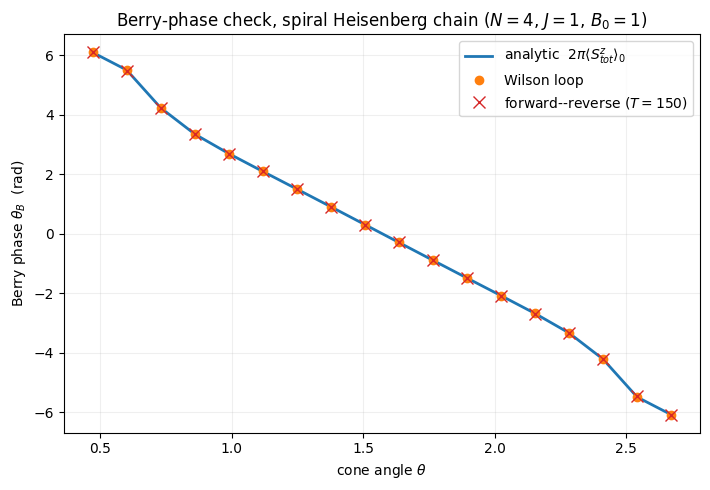

gap range over sweep: [0.109, 0.415]
max |analytic - wilson|   = 7.76e-07
max |analytic - estimate| = 1.83e-02


In [5]:
N, J, B0, T_CHECK = 4, 1.0, 1.0, 150.0
thetas = np.linspace(0.15 * np.pi, 0.85 * np.pi, 18)

analytic, wilson, estimate, gaps = [], [], [], []
for th in thetas:
    m = SpiralHeisenbergChain(N=N, J=J, B0=B0, theta=float(th))
    raw = 2.0 * np.pi * float(np.real(m.psi0.conj() @ m.Sz_tot @ m.psi0))
    analytic.append(raw)
    gaps.append(m.gap)
    wilson.append(raw + float(wrap_to_pi(berry_phase_wilson(m, 2000) - raw)))
    est = float(np.ravel(_theta_B_forward_reverse(m, T_CHECK, steps=1))[0])
    estimate.append(raw + float(wrap_to_half_pi(est - raw)))

analytic = np.array(analytic)
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(thetas, analytic, "-", lw=2, color="C0", label=r"analytic  $2\pi\langle S^z_{tot}\rangle_0$")
ax.plot(thetas, wilson, "o", ms=6, color="C1", label="Wilson loop")
ax.plot(thetas, estimate, "x", ms=8, color="C3", label=rf"forward--reverse ($T={T_CHECK:.0f}$)")
ax.set_xlabel(r"cone angle $\theta$")
ax.set_ylabel(r"Berry phase $\theta_B$  (rad)")
ax.set_title(rf"Berry-phase check, spiral Heisenberg chain ($N={N}$, $J={J:g}$, $B_0={B0:g}$)")
ax.legend()
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()
print(f"gap range over sweep: [{min(gaps):.3f}, {max(gaps):.3f}]")
print(f"max |analytic - wilson|   = {np.max(np.abs(analytic - wilson)):.2e}")
print(f"max |analytic - estimate| = {np.max(np.abs(analytic - estimate)):.2e}")

## 5. Cancellation cascade on the entangled many-qubit loop

Finally we confirm that the full cascade operates unchanged on the interacting
model. This repeats the runtime scaling of section 2 for the spiral Heisenberg chain
($N=4$, $J=1$, gap $=0.37$, $\theta_B=1.4530$). The same four estimators, applied
without modification, reproduce the hierarchy $O(T^{-1})\to O(T^{-2})\to O(T^{-4})
\to O(T^{-6})$. Because the many-body gap ($0.37$) is much smaller than the spin-$1/2$
gap ($1.0$), the prefactors are larger and the deepest curve needs a longer runtime
to settle onto its $T^{-6}$ asymptote; we therefore take $T\in[20,200]$ and a wider
randomization window $\lambda=0.8$ (wider $\lambda$ sharpens the suppression of the
oscillatory residual at the smaller gap, the relevant condition being
$\lambda\Delta_{\min}T\gtrsim1$). The result shows that the error cancellation is not
special to the exactly solvable two-level system but persists for a genuinely
entangled many-qubit adiabatic loop.

**Caption.** Error-cancellation cascade on the entangled many-qubit loop: the spiral
Heisenberg chain ($N=4$, $J=1$, $B_0=1$, gap $=0.37$), using the same four estimators
as in the spin-$1/2$ case (section 2): single ($\circ$, $T^{-1}$),
forward&ndash;reverse ($\square$, $T^{-2}$), one Richardson + bump ($\triangle$,
$T^{-4}$), two Richardson + bump ($\diamond$, $T^{-6}$); grey lines are reference
slopes. Parameters: $T\in[20,200]$ (22 points), $\alpha=1.75$, $\lambda=0.8$. The
cascade matches the spin-$1/2$ result, confirming the cancellation in a genuinely
interacting model; the smaller gap pushes the deepest curve's clean $T^{-6}$ regime
to larger $T$ (the two-level curve's downward spikes are zero crossings of the
signed bias).

N=4 spiral Heisenberg chain: gap=0.3721, theta_B=1.453012 (Wilson 1.453011)


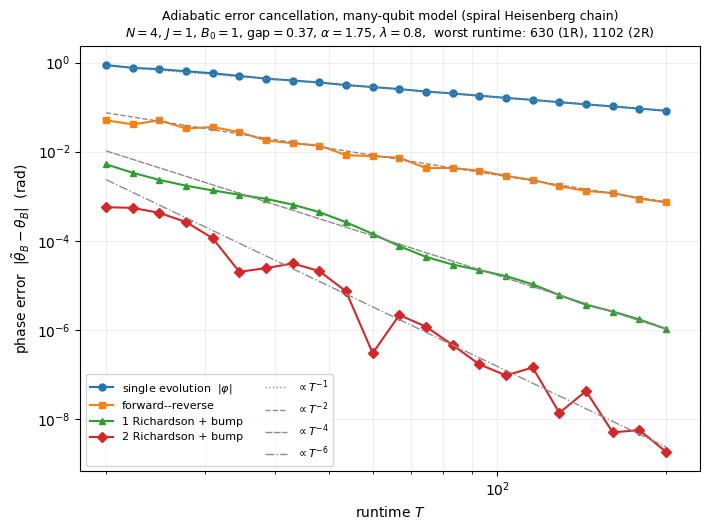

In [6]:
N, J, B0, THETA = 4, 1.0, 1.0, 0.4 * np.pi
LAM, ALPHA, T_MIN, T_MAX, N_POINTS = 0.8, 1.75, 20.0, 200.0, 22

model = SpiralHeisenbergChain(N=N, J=J, B0=B0, theta=THETA)
wl = berry_phase_wilson(model, n_points=2000)
print(f"N={N} spiral Heisenberg chain: gap={model.gap:.4f}, theta_B={model.berry_phase:.6f} (Wilson {wl:.6f})")

T = np.geomspace(T_MIN, T_MAX, N_POINTS)
e_single = single_phase_error(model, T)
e_fr = forward_reverse_error(model, T)
e_bump1 = randomized_richardson_bias(model, T, alpha=ALPHA, lam=LAM, levels=1, dist="bump")
e_bump2 = randomized_richardson_bias(model, T, alpha=ALPHA, lam=LAM, levels=2, dist="bump")

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.loglog(T, e_single, "o-", ms=5, color="C0", label=r"single evolution  $|\varphi|$")
ax.loglog(T, e_fr, "s-", ms=5, color="C1", label=r"forward--reverse")
ax.loglog(T, e_bump1, "^-", ms=5, color="C2", label=r"1 Richardson + bump")
ax.loglog(T, e_bump2, "D-", ms=5, color="C3", label=r"2 Richardson + bump")
tail = T >= np.sqrt(T_MIN * T_MAX)
for power, e, style in [(-1, e_single, ":"), (-2, e_fr, "--"), (-4, e_bump1, (0, (5, 1))), (-6, e_bump2, "-.")]:
    c = np.median(e[tail] / T[tail] ** power)
    ax.loglog(T, c * T ** power, color="0.55", lw=1.0, linestyle=style, label=rf"$\propto T^{{{power}}}$")
worst1, worst2 = T_MAX * (1.0 + LAM) * ALPHA, T_MAX * (1.0 + LAM) * ALPHA**2
params = (rf"$N={N}$, $J={J:g}$, $B_0={B0:g}$, gap$={model.gap:.2f}$, $\alpha={ALPHA:g}$, $\lambda={LAM:g}$,  "
          rf"worst runtime: {worst1:.0f} (1R), {worst2:.0f} (2R)")
ax.set_xlim(T_MIN * 0.9, T_MAX * 1.15)
ax.set_xlabel("runtime $T$")
ax.set_ylabel(r"phase error  $|\tilde\theta_B - \theta_B|$  (rad)")
ax.set_title("Adiabatic error cancellation, many-qubit model (spiral Heisenberg chain)\n" + params, fontsize=9)
ax.legend(fontsize=8, ncol=2, loc="lower left")
ax.grid(True, which="both", alpha=0.2)
fig.tight_layout()
plt.show()